# Labor Force Survey - Exploratory Data Analysis (EDA)

Created by JF Viray

This notebook is for the exploratory data analysis from the [Labor Force Survey (LFS) of April 2025](https://psada.psa.gov.ph/catalog/LFS/about). Specifically, we wish to find:
1. Find the difference in the between the youth labor force and the overall labor force
2. Composition of the Labor Force by Education Pathways
3. For each education pathway, find:
    * Unemployment
    * Employment
    * Self-Employment
    * Underemployment
    * TESDA

Below are the relevant fields from the LFS. I have also included below the description, purpose, and the codes.
| Column Name        | Description                                      | Purpose |
|--------------------|--------------------------------------------------|----------|
| PUFPWGTPRV         | Final Weight Based on Projection                | To get the estimated number (weighted estimate) of each sample |
| PUFC05_AGE          | Age as of Last Birthday                         | To get the age of the participant|
| PUFNEWEMPSTAT      | New Employment Criteria (Jul 05, 2005)          | To determine employment status |
| PUFC20_PWMORE      | Want More Hours of Work                         | To determine if underemployed |
| PUFC23_PCLASS      | Class of Worker (Primary Occupation)            | To classify worker type |
| PUFC07_GRADE       | Highest Grade Completed                         | To determine schooling level |
| PUFC09_GRADTECH    | Graduate of technical/vocational course         | To determine if TESDA graduate or not |
| PUFC25_PBASIC      | Basic Pay per Day from the Primary Occupation   | To determine the wage |

1. PUFPWGTPRV - Final Weight Based on Projection
This is in integer.

2. PUFC05_AGE - Age as of Last Birthday
This is in integer 

3. PUFNEWEMPSTAT — Employment Status

| Code | Description            |
| ---- | ---------------------- |
| 1    | Employed               |
| 2    | Unemployed             |
| 3    | Not in the Labor Force |


4. PUFC20_PWMORE — Want More Hours of Work

| Code | Description |
| ---- | ----------- |
| 1    | Yes         |
| 2    | No          |

5. PUFC23_PCLASS — Class of Worker (Primary Occupation)

| Code | Description                         |
| ---- | ----------------------------------- |
| 0    | Private Household                   |
| 1    | Private Establishment               |
| 2    | Government / Government Corporation |
| 3    | Self Employed                       |
| 4    | Employer                            |
| 5    | With Pay (Family-owned Business)    |
| 6    | Without Pay (Family-owned Business) |

6. PUFC07_GRADE — Highest Grade Completed

| Code Range    | Description                      |
| ------------- | -------------------------------- |
| 0 – 2000      | No Grade Completed               |
| 10004 – 10015 | Elementary Undergraduate         |
| 10018         | Elementary Graduate              |
| 24004 – 24013 | Junior High School Undergraduate |
| 24014 – 24015 | Junior High School Completed     |
| 34011 – 35011 | Senior High School Undergraduate |
| 34013 – 35013 | Senior High School Graduate      |
| 40001 – 50003 | Post Secondary Undergraduate     |
| 40011 – 59999 | Post Secondary Graduate          |
| 60001 – 60006 | College Undergraduate            |
| 60000 – 89999 | College Graduate                 |


7. PUFC09_GRADTECH — Graduate of Technical/Vocational Course

| Code | Description |
| ---- | ----------- |
| 1    | Yes         |
| 2    | No          |


8. PUFC25_PBASIC - Basic Pay per Day (Primary Occupation)
This is already in integers. 

# I. Cleaning the Data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set the font
from matplotlib import font_manager as fm
fpath = "Microsoft Aptos Fonts/Aptos.ttf"
prop = fm.FontProperties(fname=fpath)
#plt.rcParams['font.family'] = 'Aptos'

from matplotlib.ticker import FuncFormatter

In [33]:
# Open and combine the January and April files
relevant_cols = ['PUFPWGTPRV', # Final Weight Based on Projection
                 'PUFC05_AGE', # Age
                 'PUFNEWEMPSTAT', # Employed (1), Unemployed (2), Not in the Labor Force (3)
                 'PUFC20_PWMORE', # Underemployed (1), NOT underemployed (2)
                 'PUFC23_PCLASS', # Self-Employed (3)
                 'PUFC07_GRADE', # Look at the code
                 'PUFC09_GRADTECH', # Went through TESDA (1), Did NOT go through TESDA (2)
                 'PUFC25_PBASIC', # Pay per Day
]

# filepath = 'data/PHL-PSA-LFS-2025-01-PUF/LFS PUF January 2025.CSV'
# jan_df = pd.read_csv(filepath)

# filepath = 'data/PHL-PSA-LFS-2025-04-PUF/LFS PUF April 2025.CSV'
# apr_df = pd.read_csv(filepath)
# apr_df = apr_df[relevant_cols].replace(' ', np.nan)
# apr_df = apr_df[relevant_cols].replace('     ', np.nan)


filepath = 'data/PHL-PSA-LFS-2022-10-PUF/LFS PUF October 2022.CSV'
oct_df = pd.read_csv(filepath)
oct_df = oct_df[relevant_cols].replace(' ', np.nan)
oct_df = oct_df[relevant_cols].replace('     ', np.nan)

# combined_df = pd.concat([jan_df, apr_df])
# combined_df = combined_df[relevant_cols].replace(' ', np.nan)

In [34]:
# We don't consider the age here. We only consider the age for the youth_labor_force.ipynb
is_lf = (oct_df['PUFNEWEMPSTAT'] == '1') | (oct_df['PUFNEWEMPSTAT'] == '2')
lf_df = oct_df[is_lf].copy()

We convert the code in the PUFC07_GRADE to something actually understandable.

In [35]:
# Education code ranges
education_ranges = {
    "No grade completed": [(0, 1000), (2000, 2000)],
    "Elementary Undergraduate": [(10011, 10015), (10004, 10006)],
    "Elementary Graduate": [(10018, 10018)],
    "Junior High School Undergraduate": [(24011, 24013), (24004, 24006)],
    "Junior High School Graduate": [(24014, 24015)],
    "Senior High School Undergraduate": [(34011, 34011), (34021, 34021), (34031, 34031), (35011, 35011)],
    "Senior High School Graduate": [(34013, 34013), (34023, 34023), (34033, 34033), (35013, 35013)],
    "Post Secondary Undergraduate": [(40001, 40003), (50001, 50003)],
    "Post Secondary Graduate": [(40011, 49999), (50011, 59999)],
    "College Undergraduate": [(60001, 60006)],
    "College Graduate": [(60000, 60000), (60011, 69999), (70000, 79999), (80000, 89999)]
}

def classify_education(code):
    """Classify the code to what grade it was completed"""
    for level, ranges in education_ranges.items():
        for lower, upper in ranges:
            if lower <= code <= upper:
                return level
    return "Unknown"

# Mapping to simplified education levels: Undergraduate vs Graduate
grade_map = {
    "Junior High School Graduate": "Junior High School",
    "College Graduate": "Higher Education Institution",
    "Elementary Graduate":"Elementary",
    "Elementary Undergraduate":"No grade completed",
    "Junior High School Undergraduate":"Elementary",
    "College Undergraduate":"Senior High School",
    "Post Secondary Graduate":"Higher Education Institution",
    "Senior High School Graduate":"Senior High School",
    "No grade completed": "No grade completed",
    "Senior High School Undergraduate": "Junior High School",
    "Post Secondary Undergraduate":"Senior High School"
}

# Finally get the grade and set it as categorical
lf_df.loc[:, 'Grade'] = lf_df['PUFC07_GRADE'].astype(int).map(classify_education).map(grade_map)
grade_order = [
    "No grade completed",
    "Elementary",
    "Junior High School",
    "Senior High School",
    "Higher Education Institution"
]

# Convert the 'Grade' column to a categorical type with ordering
lf_df['Grade'] = pd.Categorical(
    lf_df['Grade'],
    categories=grade_order,
    ordered=True
)

To make sure that all of the EDA below will be correct, I checked with LFS Summary Statistics. The code has to say that there are around 49.35 people in the labor force; 47 currently employed; unemployment rate of 4.5%

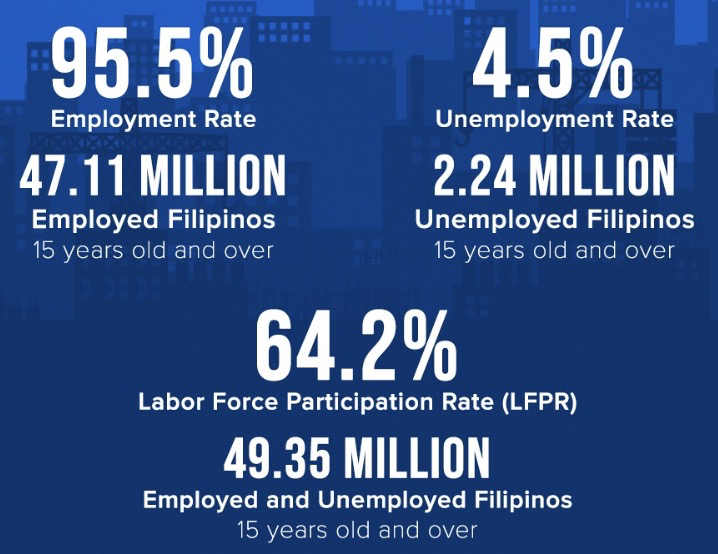

In [36]:
labor_force = lf_df['PUFPWGTPRV'].sum()
print(f"In October 2022, there were {int(labor_force)} total people in the labor force.")

employed = int(lf_df[lf_df['PUFNEWEMPSTAT'] == '1']['PUFPWGTPRV'].sum())
print(f"In October 2022, there were {int(employed)} employed people in the labor force.")

unemployment_rate = 1 - employed / labor_force
print(f"In October 2022, the unemployment rate was {unemployment_rate *100:2f}%")

In October 2022, there were 49303875 total people in the labor force.
In October 2022, there were 47063893 employed people in the labor force.
In October 2022, the unemployment rate was 4.543219%


# II. Composition of the Labor Force by Education Pathways

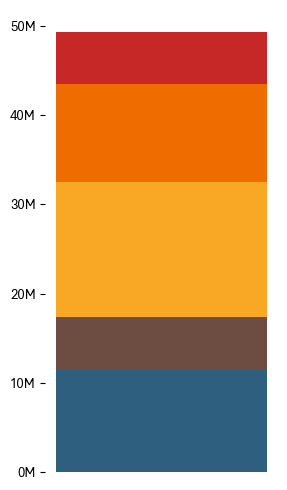

In [37]:
lf_education = lf_df.groupby('Grade', observed=False)['PUFPWGTPRV'].sum()

colors = [
    "#C62828",  # deep red
    "#EF6C00",  # orange
    "#F9A825",  # golden
    "#6D4C41",  # brown
    "#2E5F7F"   # muted blue-gray
]

fig, ax = plt.subplots(figsize=(3, 6))
bottom = 0
for (category, value), color in zip(lf_education[::-1].items(), colors[::-1]):
    plt.bar("Young Workforce", value, bottom=bottom, color=color, label=category)
    bottom += value

# Remove the spines
for spine in ['top', 'right', 'bottom', 'left']:
    plt.gca().spines[spine].set_visible(False)

# Clean the x and y axis
for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

ax.set_xticks([])
#plt.legend()
plt.show()

In [38]:
lf_education

Grade
No grade completed              5.857882e+06
Elementary                      1.097172e+07
Junior High School              1.509870e+07
Senior High School              5.941903e+06
Higher Education Institution    1.143367e+07
Name: PUFPWGTPRV, dtype: float64

In [39]:
lf_education / lf_education.sum()

Grade
No grade completed              0.118812
Elementary                      0.222533
Junior High School              0.306238
Senior High School              0.120516
Higher Education Institution    0.231902
Name: PUFPWGTPRV, dtype: float64

# II. Unemployment, Employment, Self-Employment, Underemployment, TESDA Rate of the Labor Force by Education Pathways

In [40]:
# Unemployment AND Employment
employment_grouped = lf_df.groupby(['Grade', 'PUFNEWEMPSTAT'], observed=True)['PUFPWGTPRV'].sum()


# Normalize per grade
employment_grouped_percent = employment_grouped.reset_index()
employment_grouped_percent.loc[:, 'Total'] = employment_grouped_percent.groupby('Grade', observed=True)['PUFPWGTPRV'].transform('sum')
employment_grouped_percent.loc[:, 'Percent'] = employment_grouped_percent['PUFPWGTPRV'] / employment_grouped_percent['Total']
employment_grouped_percent

,Grade,PUFNEWEMPSTAT,PUFPWGTPRV,Total,Percent
0,No grade completed,1,5.756030e+06,5.857882e+06,0.982613
1,No grade completed,2,1.018520e+05,5.857882e+06,0.017387
2,Elementary,1,1.066563e+07,1.097172e+07,0.972102
3,Elementary,2,3.060918e+05,1.097172e+07,0.027898
4,Junior High School,1,1.448698e+07,1.509870e+07,0.959485
5,Junior High School,2,6.117210e+05,1.509870e+07,0.040515
6,Senior High School,1,5.492940e+06,5.941903e+06,0.924441
7,Senior High School,2,4.489631e+05,5.941903e+06,0.075559
8,Higher Education Institution,1,1.066231e+07,1.143367e+07,0.932537
9,Higher Education Institution,2,7.713539e+05,1.143367e+07,0.067463


In [41]:
lf_df.groupby('PUFC23_PCLASS')['PUFPWGTPRV'].sum()

PUFC23_PCLASS
0    1.998881e+06
1    2.313603e+07
2    4.174949e+06
3    1.307140e+07
4    1.094398e+06
5    1.644692e+05
6    3.423767e+06
Name: PUFPWGTPRV, dtype: float64

In [42]:
# Self-Employment
type_grouped = lf_df.groupby(['Grade', 'PUFC23_PCLASS'], observed=True)['PUFPWGTPRV'].sum().reset_index()
type_grouped.loc[:, 'Total'] = type_grouped.groupby('Grade', observed=True)['PUFPWGTPRV'].transform('sum')
type_grouped.loc[:, 'Percent'] = type_grouped['PUFPWGTPRV'] / type_grouped['Total']
type_grouped[type_grouped['PUFC23_PCLASS'] == '3']

,Grade,PUFC23_PCLASS,PUFPWGTPRV,Total,Percent
3,No grade completed,3,2.497066e+06,5.756030e+06,0.433817
10,Elementary,3,3.770561e+06,1.066563e+07,0.353524
17,Junior High School,3,3.990621e+06,1.448698e+07,0.275463
24,Senior High School,3,1.178879e+06,5.492940e+06,0.214617
31,Higher Education Institution,3,1.634275e+06,1.066231e+07,0.153276


In [43]:
# UnderEmployment
under_grouped = lf_df.groupby(['Grade', 'PUFC20_PWMORE'], observed=True)['PUFPWGTPRV'].sum().reset_index()
under_grouped.loc[:, 'Total'] = under_grouped.groupby('Grade', observed=True)['PUFPWGTPRV'].transform('sum')
under_grouped.loc[:, 'Percent'] = under_grouped['PUFPWGTPRV'] / under_grouped['Total']
under_grouped[under_grouped['PUFC20_PWMORE'] == '1'] # 1 means underemployed

,Grade,PUFC20_PWMORE,PUFPWGTPRV,Total,Percent
0,No grade completed,1,1.123735e+06,5.756030e+06,0.195228
2,Elementary,1,1.849757e+06,1.066563e+07,0.173432
4,Junior High School,1,2.071118e+06,1.448698e+07,0.142964
6,Senior High School,1,6.417136e+05,5.492940e+06,0.116825
8,Higher Education Institution,1,9.789671e+05,1.066231e+07,0.091816


In [44]:
# TESDA (I will most likely not include this)
is_TESDA = lf_df['PUFC09_GRADTECH'] == '1' # 1 means they went through TESDA
tesda_df = lf_df[is_TESDA]


# UnderEmployment
under_grouped = lf_df.groupby(['Grade', 'PUFC09_GRADTECH'])['PUFPWGTPRV'].sum().reset_index()
under_grouped.loc[:, 'Total'] = under_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')
under_grouped.loc[:, 'Percent'] = under_grouped['PUFPWGTPRV'] / under_grouped['Total']
under_grouped[under_grouped['PUFC09_GRADTECH'] == '1'] # 1 means underemployed

/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_95117/1439643296.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  under_grouped = lf_df.groupby(['Grade', 'PUFC09_GRADTECH'])['PUFPWGTPRV'].sum().reset_index()
/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_95117/1439643296.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  under_grouped.loc[:, 'Total'] = under_grouped.groupby('Grade')['PUFPWGTPRV'].transform('sum')


,Grade,PUFC09_GRADTECH,PUFPWGTPRV,Total,Percent
0,No grade completed,1,1.754633e+04,5.857882e+06,0.002995
2,Elementary,1,1.385282e+05,1.097172e+07,0.012626
4,Junior High School,1,1.038424e+06,1.509870e+07,0.068776
6,Senior High School,1,2.388160e+05,5.941903e+06,0.040192
8,Higher Education Institution,1,7.645761e+05,1.143367e+07,0.066871


# III. Pay per Day

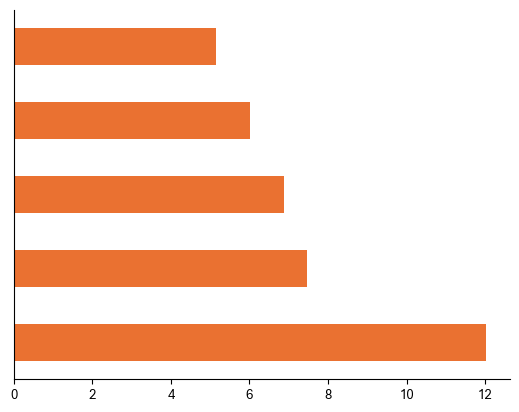

In [45]:
paid_df = lf_df.dropna(subset='PUFC25_PBASIC').copy()
paid_df.loc[:, 'PUFC25_PBASIC'] = paid_df['PUFC25_PBASIC'].astype(int)
usd_to_php = 1 / 58.23
usd_paid = paid_df.groupby('Grade', observed=True)['PUFC25_PBASIC'].median()[::-1] * usd_to_php


ax = usd_paid.plot(kind='barh', color='#EA7131')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Clean the x and y axis
for label in ax.get_xticklabels():
    label.set_fontproperties(prop)

plt.yticks([])
plt.ylabel('')

plt.show()

# IV. First Time Looking For Work

In [46]:
is_first_time = lf_df['PUFC31_FLWRK'] == '1'
new_worker_df = lf_df[is_first_time]

new_worker_df.groupby('Grade')['PUFPWGTPRV'].sum().sort_values().plot(kind='barh', color='#EA7131')

plt.ylabel('')
plt.xlabel('')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

KeyError: 'PUFC31_FLWRK'